# OMI Municipal Deep-Dive & Peer Benchmark

---

## Executive Summary

This notebook provides a **rigorous, peer-based positioning analysis** of a single Italian municipality within the OMI (*Osservatorio del Mercato Immobiliare*) real-estate dataset. Rather than analysing the target municipality in isolation, the notebook **contextualises it** against statistically comparable markets, revealing whether it is a **premium, mid-tier, or laggard** market on quotations, transaction volumes, and market composition.

The analysis is grounded in the analytical artefacts produced by two upstream notebooks:

- **`omi_quotations.parquet`** — a cleaned, residential-only panel of semiannual OMI quotations, produced by *Notebook 01*.
- **`omi_transactions_panel.parquet`** — a municipality-year panel of normalised transaction volumes (NTN), produced by *Notebook 02*.

**Key Objectives**

1. Quantify the target municipality's position on **quotations, transactions, and market composition**.
2. Define **three complementary peer groups** (provincial, dimensional, top-N) to triangulate the result.
3. Compute **percentile rankings, growth metrics, and risk indicators** (CAGR, volatility, max drawdown).
4. Produce a **reproducible, extensible report** that can be re-run on any Italian municipality.

**Methodological Note on Peer Selection**  
Since municipal population is not available in the OMI datasets, **market size is approximated by the total transaction volume** (`ntn_res + ntn_non_res`). If a demographic source is integrated in the future, a single merge on `(year, codcom)` will suffice to refine the peer definition; the rest of the notebook will work unchanged.

---

## Table of Contents

1. **Setup & Configuration**
2. **Data Loading & Integration**
    - 2.1 Load artefacts from upstream notebooks
    - 2.2 Key normalisation
    - 2.3 Quotation aggregation at comune-year level
    - 2.4 Unified analytical panel
3. **Target Municipality Selection**
    - 3.1 Reference period
    - 3.2 Target profile
4. **Peer Group Construction**
    - 4.1 Peer definition (provincial, dimensional, top-N)
    - 4.2 Peer group sizes
5. **Benchmark Analysis**
    - 5.1 Benchmark table
    - 5.2 Percentile ranking
    - 5.3 Distribution comparison (boxplots)
6. **Time-Series Analysis**
    - 6.1 Residential transactions
    - 6.2 Quotations
    - 6.3 Non-residential transactions
    - 6.4 Indexed comparison
7. **Multivariate Positioning**
    - 7.1 Quotation vs transaction volume
    - 7.2 Quotation vs residential share
8. **Market Composition**
    - 8.1 Size-band composition
9. **Risk & Return Analytics**
10. **Summary & Insights**
11. **Export**

---

## 1. Setup & Configuration

The analytical stack is intentionally lightweight: `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, `scipy` for statistical tests. Configuration constants are declared at the top to guarantee methodological consistency and reproducibility.

Three sets of parameters govern the analysis:

- **Target parameters** — the municipality under investigation and the reference year.
- **Peer parameters** — the tolerance band and size thresholds for peer groups.
- **Path resolution** — automatic discovery of the processed-data directory.

In [1]:
# Cell 1: Imports and global configuration
from pathlib import Path
import unicodedata
import warnings
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# Professional plotting style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Cell 2: Resolve project paths and analysis parameters
def resolve_project_root() -> Path:
    """Locate the project root by walking up from the CWD."""
    root = Path.cwd()
    for candidate in [root, *root.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 'data/'.")

PROJECT_ROOT = resolve_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
BENCHMARK_DIR = PROCESSED_DIR / "benchmark"

# === TARGET MUNICIPALITY =====================================================
TARGET_COMUNE: str = "BRESCIA"
LATEST_YEAR: Optional[int] = None

# === PEER GROUP DEFINITION ===================================================
PEER_VOL_TOL: float = 0.50
MIN_PEERS: int = 8
TOP_N_PROV: int = 30

# === RISK METRICS ============================================================
MIN_OBS_FOR_RISK: int = 3
PERIODS_PER_YEAR: int = 1  # annual quotations

---

## 2. Data Loading & Integration

This section reconstructs the **integrated comune-year panel** required for peer benchmarking. It combines:

- the **transaction side** (from Notebook 02), which provides municipality-level NTN for residential and non-residential segments, and size-band breakdowns;
- the **quotation side** (from Notebook 01), which provides residential €/m² statistics per municipality and semester.

### 2.1 Load artefacts from upstream notebooks

In [3]:
# Cell 3: Load artefacts from Notebook 01 and Notebook 02
def load_parquet(name: str) -> pd.DataFrame:
    path = PROCESSED_DIR / name
    if not path.exists():
        raise FileNotFoundError(
            f"Missing artefact: {path}. Run upstream notebooks first."
        )
    return pd.read_parquet(path)

quot = load_parquet("omi_quotations.parquet")
trans = load_parquet("omi_transactions_panel.parquet")

print(f"Quotations artefact        : {quot.shape[0]:>10,} rows × {quot.shape[1]:>3} columns")
print(f"Transactions panel artefact: {trans.shape[0]:>10,} rows × {trans.shape[1]:>3} columns")

Quotations artefact        :  7,516,495 rows ×  36 columns
Transactions panel artefact:    114,262 rows ×  14 columns


> **Insight.** Both artefacts are loaded directly from the processed-data layer, guaranteeing reproducibility. No re-processing of raw OMI releases is required at this stage.

### 2.2 Key normalisation

Municipality names in the OMI quotations and in the transactions panel can differ in casing, accents, and whitespace. A single normalisation function ensures reliable joins across sources.

In [4]:
# Cell 4: Normalise municipality and region keys
def normalise_key(s: pd.Series) -> pd.Series:
    """
    Normalise a string Series for robust joins:
    - uppercase
    - strip whitespace
    - remove accents (NFKD → ASCII)
    Returns a plain object-dtype Series (not pandas 'string' dtype)
    to avoid merge/comparison pitfalls.
    """
    if s is None:
        return s
    result = s.astype(object).where(s.notna(), None)

    def _clean(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        x = str(x).upper().strip()
        return unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode()

    return result.map(_clean)

# Quotations side
quot["Regione_n"] = normalise_key(quot["Regione"])
quot["Prov_n"]    = normalise_key(quot["Prov"])
quot["Comune_n"]  = normalise_key(quot["Comune_descrizione"])

# Transactions panel side
trans["Regione_n"] = normalise_key(trans["regione"])
trans["Comune_n"]  = normalise_key(trans["comune"])

print("Normalisation complete.")
print(f"  Quotations  → unique comuni: {quot['Comune_n'].nunique():,}")
print(f"  Transactions → unique comuni: {trans['Comune_n'].nunique():,}")

Normalisation complete.
  Quotations  → unique comuni: 8,220
  Transactions → unique comuni: 7,805


### 2.3 Quotation aggregation at comune-year level

The quotations artefact is originally keyed at the semester level. For peer benchmarking against annual transaction data, we aggregate **residential** quotations to the **comune-year** level using robust statistics (medians for central tendency, quantiles for dispersion).

In [5]:
# Cell 5: Aggregate residential quotations at comune-year level
RESIDENTIAL_PATTERN = r"abitazion|villa"

res_mask = (
    quot["Descr_Tipologia"]
    .astype(object)
    .str.contains(RESIDENTIAL_PATTERN, case=False, na=False)
)
res = quot.loc[res_mask].copy()
res = res.dropna(subset=["Compr_mid"])

quot_annual = (
    res.groupby(["reference_year", "Regione_n", "Prov_n", "Comune_n"], as_index=False)
       .agg(
           compr_mid_median  = ("Compr_mid", "median"),
           compr_mid_mean    = ("Compr_mid", "mean"),
           compr_min_median  = ("Compr_min", "median"),
           compr_max_median  = ("Compr_max", "median"),
           spread_pct_median = ("Compr_spread_pct", "median"),
           compr_obs         = ("Compr_mid", "size"),
       )
       .rename(columns={"reference_year": "year"})
)

print(f"Aggregated quotations: {len(quot_annual):,} comune-year rows")
display(quot_annual.head(5))

Aggregated quotations: 173,962 comune-year rows


,year,Regione_n,Prov_n,Comune_n,compr_mid_median,compr_mid_mean,compr_min_median,compr_max_median,spread_pct_median,compr_obs
0,2004,ABRUZZO,AQ,ACCIANO,360.00,360.00,290.00,430.00,38.99,8
1,2004,ABRUZZO,AQ,AIELLI,525.00,518.75,420.00,630.00,38.26,8
2,2004,ABRUZZO,AQ,ALFEDENA,840.00,837.50,675.00,"1,005.00",39.00,8
3,2004,ABRUZZO,AQ,ANVERSA DEGLI ABRUZZI,420.00,420.00,345.00,495.00,35.84,8
4,2004,ABRUZZO,AQ,ATELETA,525.00,518.75,420.00,630.00,38.26,8


### 2.4 Unified analytical panel

The transaction panel and the aggregated quotations are joined on `(year, Regione_n, Comune_n)`. A **total volume** column is derived as a proxy for market size, and year-over-year growth metrics are computed for both quotations and transactions.

In [6]:
# Cell 6: Merge and enrich the analytical panel (deduplicated)
def dedupe(df: pd.DataFrame, subset: List[str], sort_col: str) -> pd.DataFrame:
    """Keep the record with the highest value in `sort_col` per `subset`."""
    return (
        df.sort_values(sort_col, ascending=False)
          .drop_duplicates(subset=subset, keep="first")
          .copy()
    )

trans_dedup = dedupe(trans, ["year", "Regione_n", "Comune_n"], "ntn_res")
quot_dedup  = dedupe(quot_annual, ["year", "Regione_n", "Comune_n"], "compr_obs")

panel = trans_dedup.merge(
    quot_dedup,
    on=["year", "Regione_n", "Comune_n"],
    how="left",
    validate="one_to_one",
)

# Enrichment
panel = panel.sort_values(["Comune_n", "year"]).reset_index(drop=True)
panel["compr_yoy"] = panel.groupby("Comune_n")["compr_mid_median"].pct_change()
panel["ntn_yoy"]   = panel.groupby("Comune_n")["ntn_res"].pct_change()
panel["vol_tot"]   = panel["ntn_res"].fillna(0) + panel["ntn_non_res"].fillna(0)

# Guard against non-positive volumes
panel.loc[panel["vol_tot"] <= 0, "vol_tot"] = np.nan

print(f"Unified panel        : {panel.shape[0]:,} rows × {panel.shape[1]} columns")
print(f"Quotation coverage   : {panel['compr_mid_median'].notna().mean():.1%}")
print(f"Year range           : {int(panel['year'].min())}–{int(panel['year'].max())}")
print(f"Municipalities       : {panel['Comune_n'].nunique():,}")

Unified panel        : 114,258 rows × 26 columns
Quotation coverage   : 94.8%
Year range           : 2011–2025
Municipalities       : 7,805


> **Insight.** The unified panel combines transaction volumes, quotation levels, and market-size proxies on a common municipality-year key. This is the analytical foundation for every subsequent comparison.

---

## 3. Target Municipality Selection

### 3.1 Reference period

The reference year is either explicitly configured or automatically resolved to the latest year available in the panel.

In [7]:
# Cell 7: Resolve reference year
if LATEST_YEAR is None:
    LATEST_YEAR = int(panel["year"].max())
print(f"Reference year: {LATEST_YEAR}")

Reference year: 2025


### 3.2 Target profile

The target municipality is retrieved from the panel for the reference year. If the name cannot be resolved, up to ten closest candidates are suggested to facilitate correction.

In [8]:
# Cell 8: Retrieve the target municipality row
target_key = normalise_key(pd.Series([TARGET_COMUNE])).iloc[0]

target_rows = panel[(panel["Comune_n"] == target_key) & (panel["year"] == LATEST_YEAR)]

if target_rows.empty:
    available = sorted(panel["Comune_n"].dropna().unique())
    matches = [c for c in available if TARGET_COMUNE.upper() in c][:10]
    raise ValueError(
        f"Municipality '{TARGET_COMUNE}' not found for year {LATEST_YEAR}.\n"
        f"Suggestions: {matches or 'none'}"
    )

target = target_rows.iloc[0]

def fmt_eur(x):
    return f"{x:,.0f} €/m²" if pd.notna(x) else "n/a"

profile = pd.Series({
    "Municipality":        target["comune"],
    "Province":            target.get("provincia", target.get("Prov_n", "n/a")),
    "Region":              target["Regione_n"],
    "Reference year":      LATEST_YEAR,
    "Residential NTN":     f"{target['ntn_res']:,.2f}",
    "Non-residential NTN": f"{target['ntn_non_res']:,.2f}",
    "Total volume":        f"{target['vol_tot']:,.2f}",
    "Median quotation":    fmt_eur(target["compr_mid_median"]),
    "Spread %":            f"{target['spread_pct_median']:.1f}%" if pd.notna(target["spread_pct_median"]) else "n/a",
}, name="value")

display(profile.to_frame())

,value
Municipality,BRESCIA
Province,BS
Region,LOMBARDIA
Reference year,2025
Residential NTN,"3,199.06"
Non-residential NTN,"4,379.94"
Total volume,"7,579.00"
Median quotation,"1,725 €/m²"
Spread %,23.1%


> **Insight.** The target municipality's profile is summarised on the key analytical dimensions. This snapshot provides the reference values used in every subsequent comparison.

---

## 4. Peer Group Construction

### 4.1 Peer definition

To triangulate the target's position, **three complementary peer groups** are constructed:

| Peer Group | Definition | Purpose |
|---|---|---|
| **Provincial** | All municipalities in the same province | Broad geographic context |
| **Dimensional** | Same region + total volume within ±50% | Controls for market size |
| **Top-N provincial** | Top-N municipalities in the province by total volume | Premium / benchmark cluster |

A **fallback rule** ensures that if the dimensional peer group is too small (< `MIN_PEERS`), it is replaced by the top-N provincial group.

In [9]:
# Cell 9: Build peer groups
latest = (
    panel[panel["year"] == LATEST_YEAR]
    .dropna(subset=["ntn_res", "compr_mid_median", "vol_tot"])
    .copy()
)
latest = latest[latest["Comune_n"] != target["Comune_n"]]

peer_prov = latest[latest["Prov_n"] == target["Prov_n"]].copy()

peer_dim = latest[
    (latest["Regione_n"] == target["Regione_n"]) &
    (latest["vol_tot"].between(
        target["vol_tot"] * (1 - PEER_VOL_TOL),
        target["vol_tot"] * (1 + PEER_VOL_TOL),
    ))
].copy()

peer_top = peer_prov.nlargest(TOP_N_PROV, "vol_tot").copy()

# Fallback BEFORE constructing the dict
if len(peer_dim) < MIN_PEERS:
    print(f"[warn] Dimensional peers insufficient ({len(peer_dim)}). "
          f"Falling back to top-{TOP_N_PROV} provincial peers.")
    peer_dim = peer_top.copy()

peer_groups: Dict[str, pd.DataFrame] = {
    "Provincial":                   peer_prov,
    "Dimensional (region)":         peer_dim,
    f"Top-{TOP_N_PROV} provincial":  peer_top,
}

# Freeze peer names NOW (used later in plots)
peer_names = peer_dim["Comune_n"].tolist()

[warn] Dimensional peers insufficient (2). Falling back to top-30 provincial peers.


### 4.2 Peer group sizes

In [10]:
# Cell 10: Peer group summary
peer_summary = pd.DataFrame({
    "Peer group":             list(peer_groups.keys()),
    "Municipalities":         [len(df) for df in peer_groups.values()],
    "Median total volume":    [df["vol_tot"].median() for df in peer_groups.values()],
    "Median quotation €/m²":  [df["compr_mid_median"].median() for df in peer_groups.values()],
})

display(peer_summary.style.format({
    "Municipalities":        "{:.0f}",
    "Median total volume":   "{:,.0f}",
    "Median quotation €/m²": "{:,.0f}",
}))

,Peer group,Municipalities,Median total volume,Median quotation €/m²
0,Provincial,202,103,"1,160"
1,Dimensional (region),30,423,"1,331"
2,Top-30 provincial,30,423,"1,331"


> **Insight.** Each peer group captures a different market signal: the **provincial** set reflects local geography, the **dimensional** set isolates similar-sized markets, and the **top-N** set represents the premium cluster. Agreement across the three strengthens the reliability of the conclusions.

---

## 5. Benchmark Analysis

### 5.1 Benchmark table

For each peer group, the target's value is compared against the peer median and interquartile range, and a **percentile rank** is computed.

In [11]:
# Cell 11: Benchmark table helper
def benchmark_row(df: pd.DataFrame, target_value, col: str) -> pd.Series:
    """Compare a target value against a peer column, returning key stats."""
    v = df[col].dropna()
    if v.empty:
        return pd.Series({
            "target": target_value,
            "peer_median": np.nan,
            "peer_p25": np.nan,
            "peer_p75": np.nan,
            "target_percentile": np.nan,
            "peer_count": 0,
        })
    pct = (v < target_value).mean() * 100 if pd.notna(target_value) else np.nan
    return pd.Series({
        "target":            target_value,
        "peer_median":       v.median(),
        "peer_p25":          v.quantile(0.25),
        "peer_p75":          v.quantile(0.75),
        "target_percentile": pct,
        "peer_count":        len(v),
    })

metrics = {
    "Residential NTN":               "ntn_res",
    "Non-residential NTN":           "ntn_non_res",
    "Total volume":                  "vol_tot",
    "Median quotation €/m²":         "compr_mid_median",
    "Median minimum quotation €/m²": "compr_min_median",
    "Median maximum quotation €/m²": "compr_max_median",
    "Median spread %":               "spread_pct_median",
}

benchmarks: Dict[str, pd.DataFrame] = {
    name: pd.DataFrame({
        m: benchmark_row(pg, target.get(col, np.nan), col)
        for m, col in metrics.items()
    }).T
    for name, pg in peer_groups.items()
}

In [12]:
# Cell 12: Display benchmark for the most informative peer group
key_show = "Dimensional (region)" if "Dimensional (region)" in benchmarks else next(iter(benchmarks))
print(f"=== Benchmark against '{key_show}' peers ({LATEST_YEAR}) ===")
display(
    benchmarks[key_show].style.format({
        "target":            "{:,.2f}",
        "peer_median":       "{:,.2f}",
        "peer_p25":          "{:,.2f}",
        "peer_p75":          "{:,.2f}",
        "target_percentile": "{:.1f}%",
        "peer_count":        "{:.0f}",
    })
)

=== Benchmark against 'Dimensional (region)' peers (2025) ===


,target,peer_median,peer_p25,peer_p75,target_percentile,peer_count
Residential NTN,"3,199.06",187.97,163.21,247.65,100.0%,30
Non-residential NTN,"4,379.94",237.81,198.87,299.93,100.0%,30
Total volume,"7,579.00",423.26,368.56,507.81,100.0%,30
Median quotation €/m²,"1,725.00","1,331.25","1,250.00","1,687.50",76.7%,30
Median minimum quotation €/m²,"1,500.00","1,162.50","1,100.00","1,468.75",76.7%,30
Median maximum quotation €/m²,"1,950.00","1,500.00","1,406.25","1,906.25",76.7%,30
Median spread %,23.08,24.88,23.75,28.44,20.0%,30


> **Insight.** The benchmark table quantifies how the target municipality compares to similar markets. Values above the 75th percentile indicate a premium positioning; values below the 25th percentile indicate a laggard market. The percentile column allows direct, scale-free comparison across heterogeneous metrics.

### 5.2 Percentile ranking across peer groups

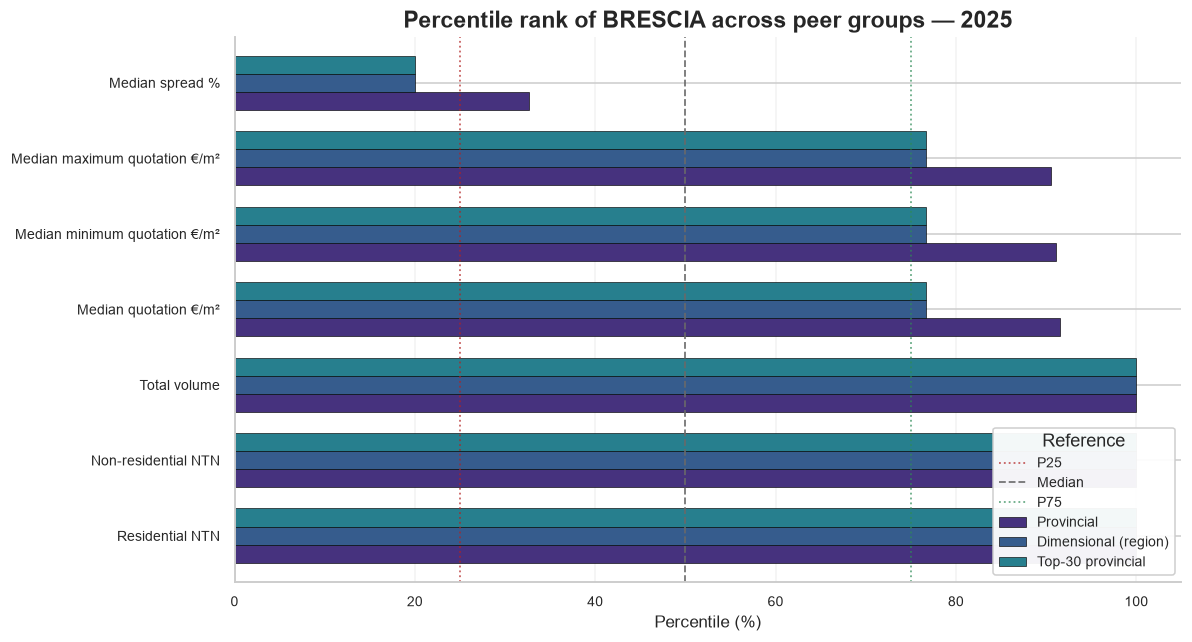

In [13]:
# Cell 13: Percentile rank visualisation
pct_table = pd.DataFrame({name: benchmarks[name]["target_percentile"] for name in benchmarks})

fig, ax = plt.subplots(figsize=(11, 6))
pct_table.plot(kind="barh", ax=ax, width=0.72, edgecolor="black", linewidth=0.4)

# Reference bands
ax.axvline(25, color="firebrick",  linestyle=":",  linewidth=1.2, alpha=0.7, label="P25")
ax.axvline(50, color="dimgrey",   linestyle="--", linewidth=1.2, alpha=0.9, label="Median")
ax.axvline(75, color="seagreen",  linestyle=":",  linewidth=1.2, alpha=0.7, label="P75")

ax.set(
    title=f"Percentile rank of {target['comune']} across peer groups — {LATEST_YEAR}",
    xlabel="Percentile (%)",
    ylabel="",
    xlim=(0, 105),
)
ax.legend(title="Reference", loc="lower right", framealpha=0.95)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

> **Insight.** Percentile rankings across multiple peer groups reveal whether the target's positioning is **robust** (consistent across definitions) or **context-dependent** (only exceptional within a specific reference set).

### 5.3 Distribution comparison (boxplots)

Boxplots of the provincial peer distribution give an immediate visual sense of where the target lies relative to the interquartile range and outliers.

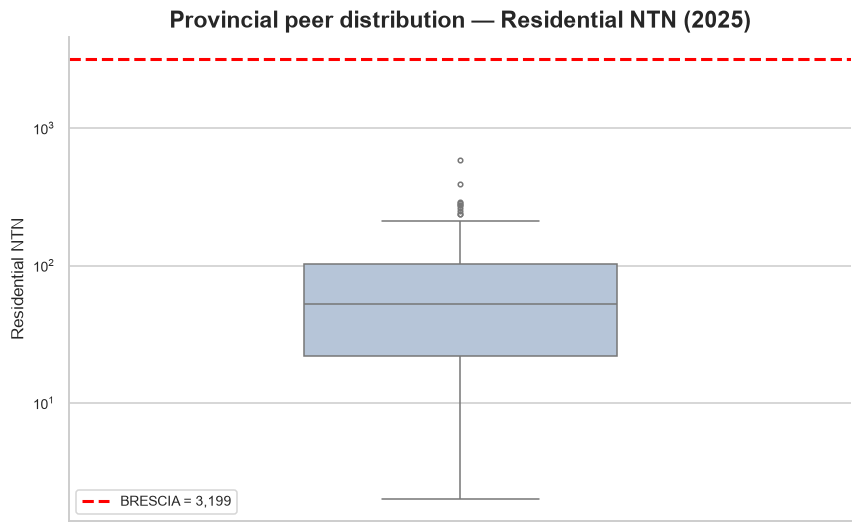

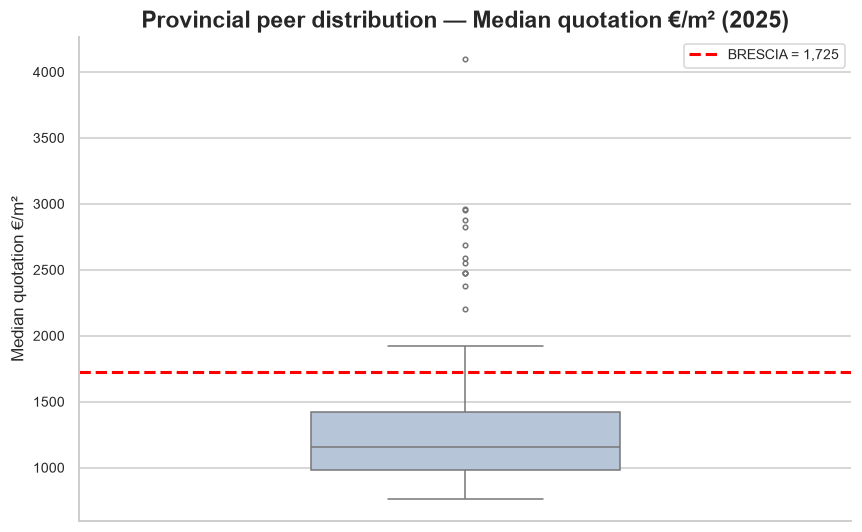

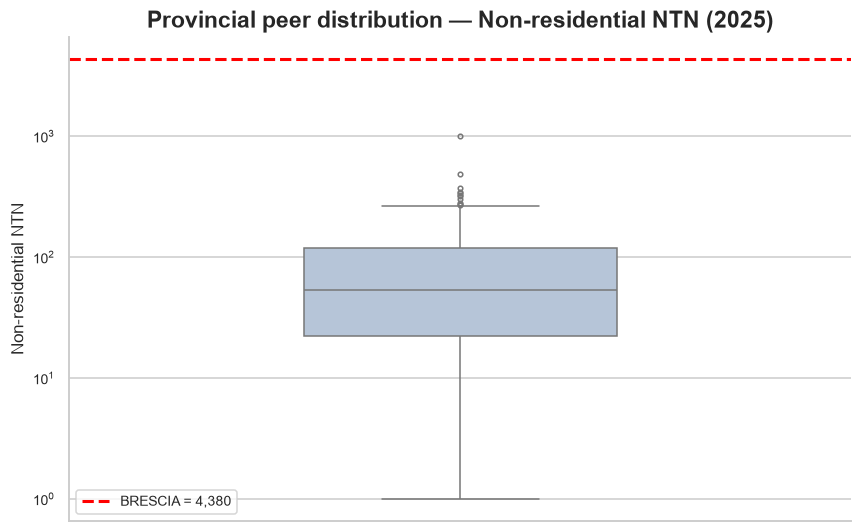

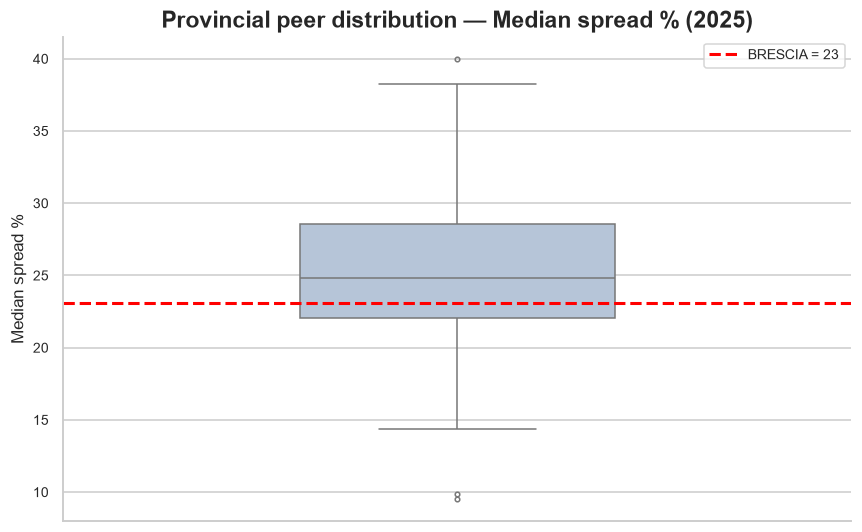

In [14]:
# Cell 14: Boxplots with target line
for col, title, log_axis in [
    ("ntn_res",           "Residential NTN",       True),
    ("compr_mid_median",  "Median quotation €/m²", False),
    ("ntn_non_res",       "Non-residential NTN",   True),
    ("spread_pct_median", "Median spread %",       False),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(y=peer_prov[col].dropna(), ax=ax, color="lightsteelblue",
                width=0.4, fliersize=3)
    tv = target.get(col, np.nan)
    if pd.notna(tv):
        ax.axhline(tv, color="red", linestyle="--", linewidth=2,
                   label=f"{target['comune']} = {tv:,.0f}")
        ax.legend(loc="best")
    if log_axis:
        ax.set_yscale("log")
    ax.set(title=f"Provincial peer distribution — {title} ({LATEST_YEAR})",
           ylabel=title)
    plt.tight_layout()
    plt.show()

---

## 6. Time-Series Analysis

While the benchmark table captures the target's positioning in the most recent year, this section examines **how the gap has evolved over time**. Trends are contrasted against the peer median, which acts as a moving benchmark.

### 6.1 Residential transactions

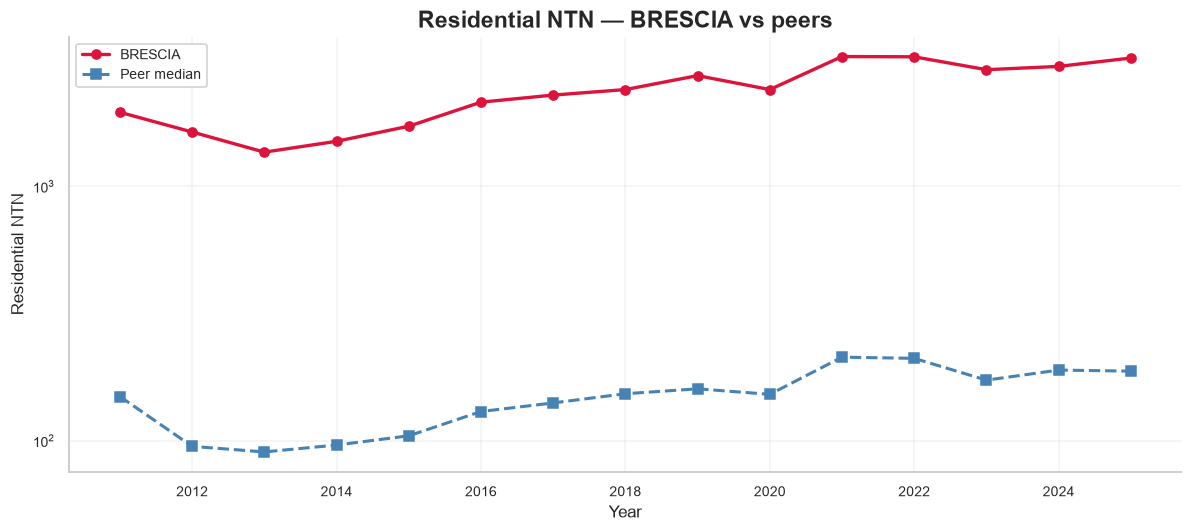

In [15]:
# Cell 15: Time-series helper
def plot_target_vs_peer(
    panel: pd.DataFrame,
    target_name: str,
    peer_names: List[str],
    col: str,
    title: str,
    ylabel: str,
    log: bool = False,
) -> None:
    tgt = panel[panel["Comune_n"] == target_name].sort_values("year")
    prs = (
        panel[panel["Comune_n"].isin(peer_names)]
        .groupby("year")[col].median()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(tgt["year"], tgt[col], marker="o", linewidth=2.2,
            label=target["comune"], color="crimson")
    ax.plot(prs["year"], prs[col], marker="s", linestyle="--", linewidth=2,
            label="Peer median", color="steelblue")
    if log:
        ax.set_yscale("log")
    ax.set(title=title, xlabel="Year", ylabel=ylabel)
    ax.legend(framealpha=0.95)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_target_vs_peer(
    panel, target["Comune_n"], peer_names,
    "ntn_res",
    f"Residential NTN — {target['comune']} vs peers",
    "Residential NTN", log=True,
)

### 6.2 Quotations

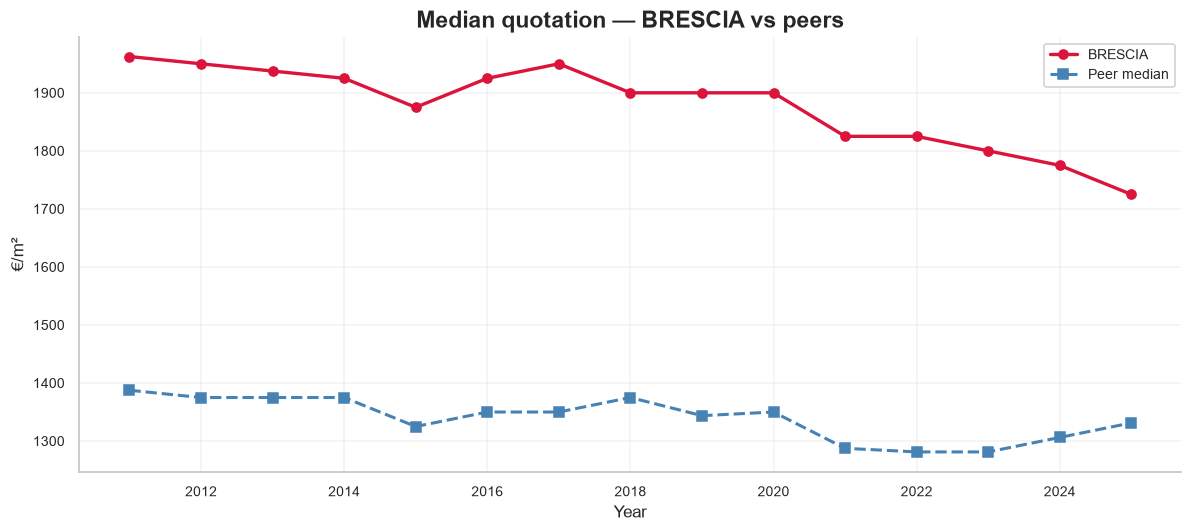

In [16]:
# Cell 16: Quotation time series
plot_target_vs_peer(
    panel, target["Comune_n"], peer_names,
    "compr_mid_median",
    f"Median quotation — {target['comune']} vs peers",
    "€/m²",
)

### 6.3 Non-residential transactions

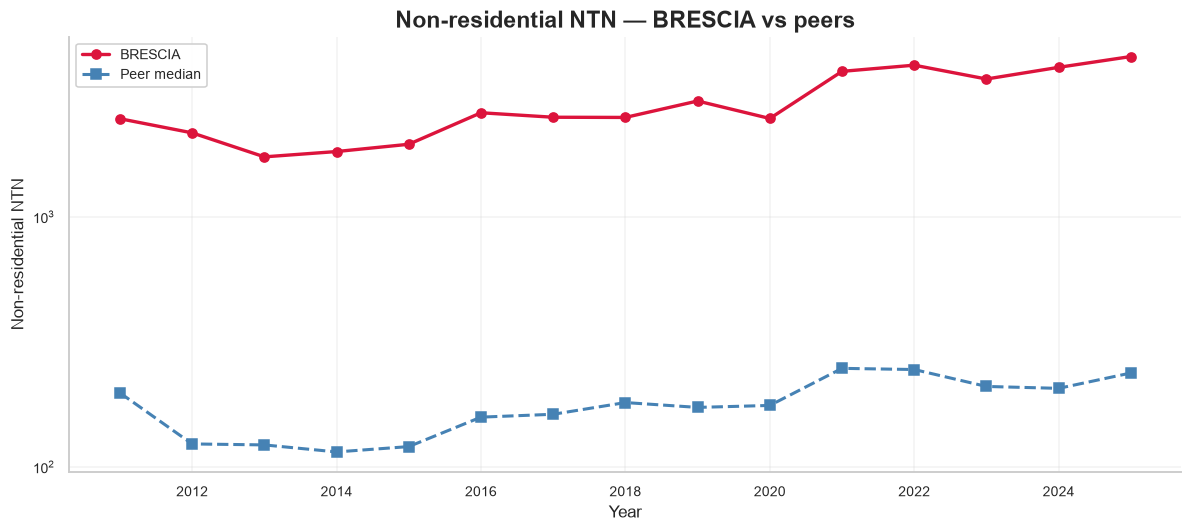

In [17]:
# Cell 17: Non-residential NTN time series
plot_target_vs_peer(
    panel, target["Comune_n"], peer_names,
    "ntn_non_res",
    f"Non-residential NTN — {target['comune']} vs peers",
    "Non-residential NTN", log=True,
)

### 6.4 Indexed comparison

To remove the confounding effect of differing price levels, quotations are **indexed to the first year** of the panel, isolating the cumulative growth differential between the target and its peers.

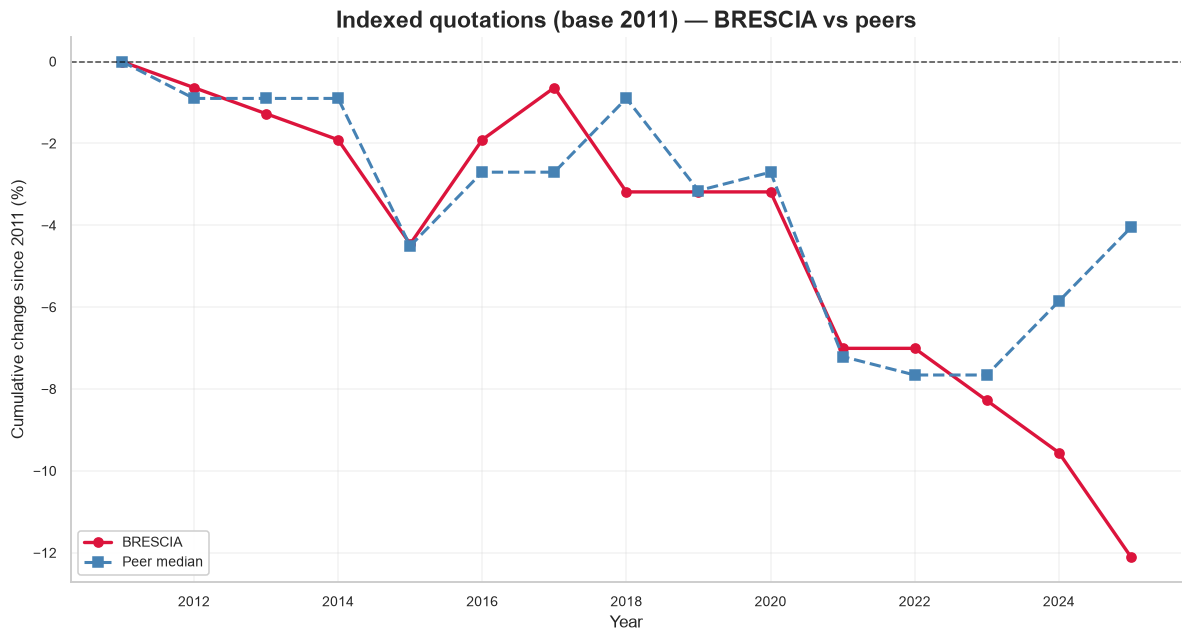

In [18]:
# Cell 18: Indexed quotation trend
def indexed_series(s: pd.Series, base_year: int) -> pd.Series:
    """Rebase a series to 0 at `base_year`, returning cumulative % change."""
    s = s.dropna().sort_index()
    if base_year not in s.index:
        warnings.warn(f"Base year {base_year} not found in series; returning empty.")
        return pd.Series(dtype=float)
    base = s.loc[base_year]
    if base <= 0:
        warnings.warn(f"Base value at {base_year} is non-positive; returning empty.")
        return pd.Series(dtype=float)
    return (s / base - 1) * 100

target_hist = (
    panel[panel["Comune_n"] == target["Comune_n"]]
    .set_index("year")["compr_mid_median"]
)
peer_hist = (
    panel[panel["Comune_n"].isin(peer_names)]
    .groupby("year")["compr_mid_median"].median()
)

base_year = int(panel["year"].min())
tgt_idx  = indexed_series(target_hist, base_year)
peer_idx = indexed_series(peer_hist,   base_year)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(tgt_idx.index,  tgt_idx.values,  marker="o", linewidth=2.2,
        label=target["comune"], color="crimson")
ax.plot(peer_idx.index, peer_idx.values, marker="s", linestyle="--", linewidth=2,
        label="Peer median", color="steelblue")
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set(
    title=f"Indexed quotations (base {base_year}) — {target['comune']} vs peers",
    xlabel="Year",
    ylabel=f"Cumulative change since {base_year} (%)",
)
ax.legend(framealpha=0.95)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

> **Insight.** The indexed comparison isolates **relative performance**: a target line consistently above the peer median signals sustained outperformance; a converging or diverging pattern signals changing market dynamics.

---

## 7. Multivariate Positioning

This section places the target municipality in a **two-dimensional competitive space**, revealing whether its price level is justified by market activity, and whether its market is skewed towards residential or non-residential segments.

### 7.1 Quotation vs transaction volume

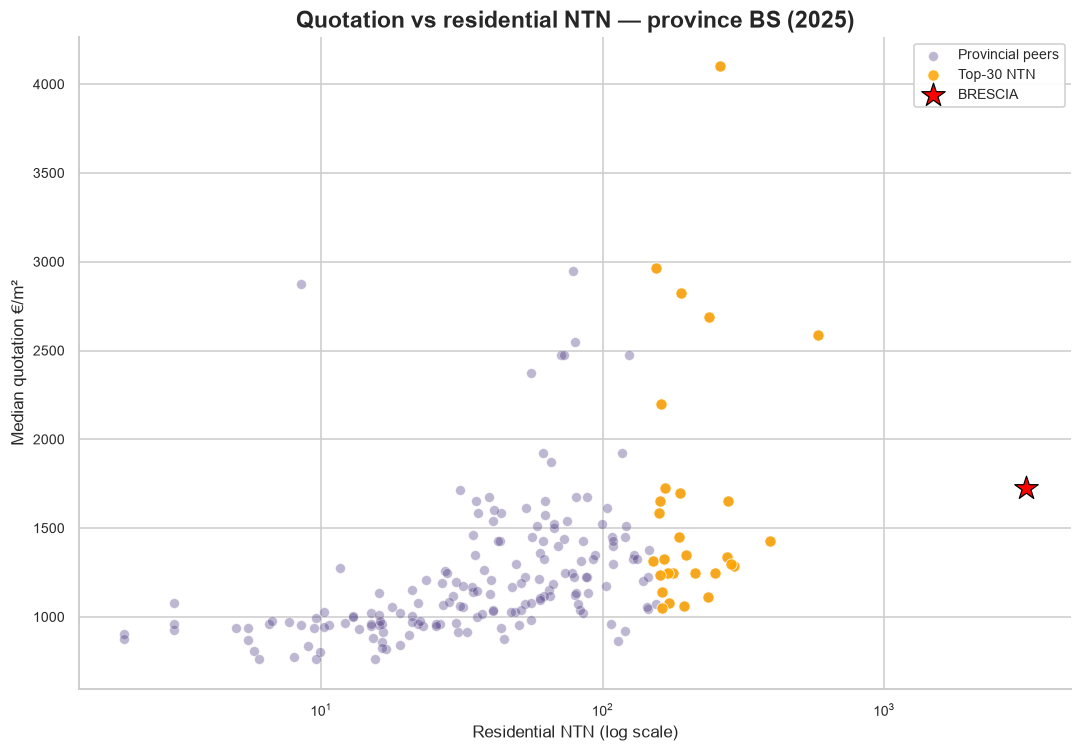

In [19]:
# Cell 19: Quotation vs residential NTN
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=peer_prov, x="ntn_res", y="compr_mid_median",
    alpha=0.35, ax=ax, label="Provincial peers", s=40,
)
sns.scatterplot(
    data=peer_top, x="ntn_res", y="compr_mid_median",
    alpha=0.85, ax=ax, color="orange", label=f"Top-{TOP_N_PROV} NTN", s=55,
)
ax.scatter(
    target["ntn_res"], target["compr_mid_median"],
    color="red", s=260, marker="*", zorder=5,
    label=target["comune"], edgecolor="black", linewidth=0.8,
)
ax.set(
    title=f"Quotation vs residential NTN — province {target['Prov_n']} ({LATEST_YEAR})",
    xlabel="Residential NTN (log scale)",
    ylabel="Median quotation €/m²",
)
ax.set_xscale("log")
ax.legend(framealpha=0.95)
plt.tight_layout()
plt.show()

> **Insight.** The upper-right quadrant identifies **large and expensive** markets (typically provincial capitals and tourist hubs). The upper-left identifies **small but premium** markets (exclusive resorts, historic centres). The target's quadrant classifies its fundamental competitive nature.

### 7.2 Quotation vs residential share

The **residential share** (residential NTN / total NTN) captures the structural orientation of the local market — whether it is dominated by households or by businesses.

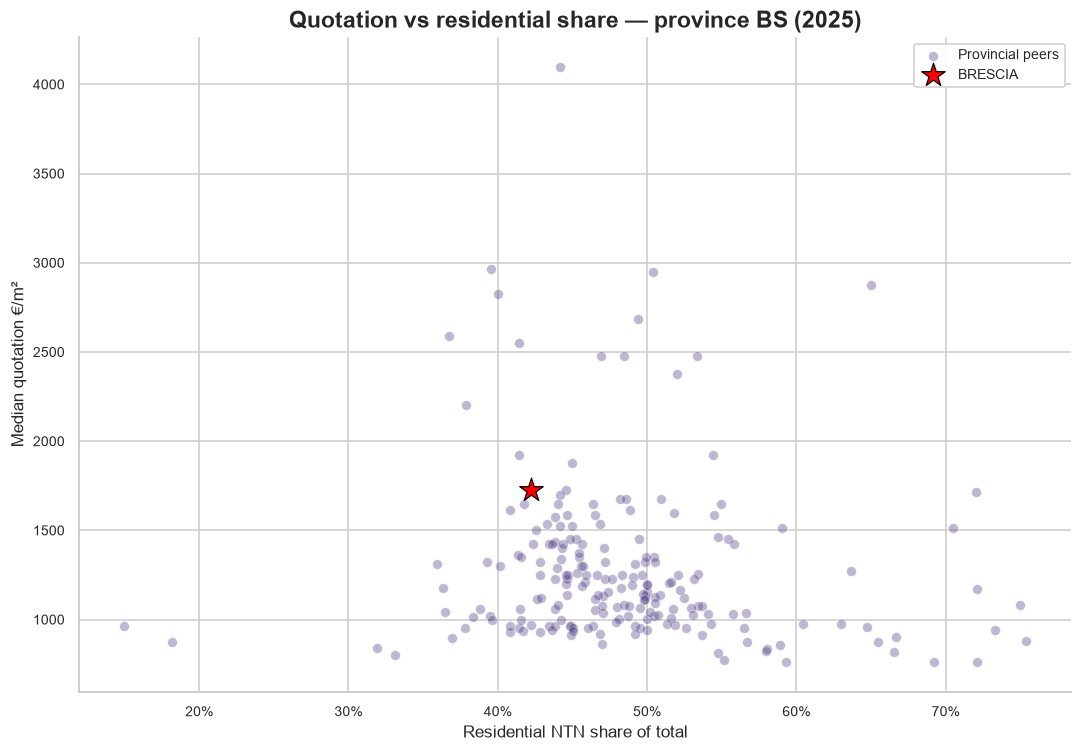

In [20]:
# Cell 20: Quotation vs residential share
def add_residential_share(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    total = df["ntn_res"] + df["ntn_non_res"]
    df["share_res"] = np.where(total > 0, df["ntn_res"] / total, np.nan)
    return df

peer_prov = add_residential_share(peer_prov)
peer_top  = add_residential_share(peer_top)

total_target = target["ntn_res"] + target["ntn_non_res"]
target_share = target["ntn_res"] / total_target if total_target > 0 else np.nan

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=peer_prov, x="share_res", y="compr_mid_median",
    alpha=0.35, ax=ax, label="Provincial peers", s=40,
)
if pd.notna(target_share):
    ax.scatter(
        target_share, target["compr_mid_median"],
        color="red", s=260, marker="*", zorder=5,
        label=target["comune"], edgecolor="black", linewidth=0.8,
    )
ax.set(
    title=f"Quotation vs residential share — province {target['Prov_n']} ({LATEST_YEAR})",
    xlabel="Residential NTN share of total",
    ylabel="Median quotation €/m²",
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(framealpha=0.95)
plt.tight_layout()
plt.show()

---

## 8. Market Composition

### 8.1 Size-band composition

The OMI residential dataset classifies transactions into five official size bands. Comparing the target's composition against the peer median reveals **structural differences** in the housing stock and buyer preferences.

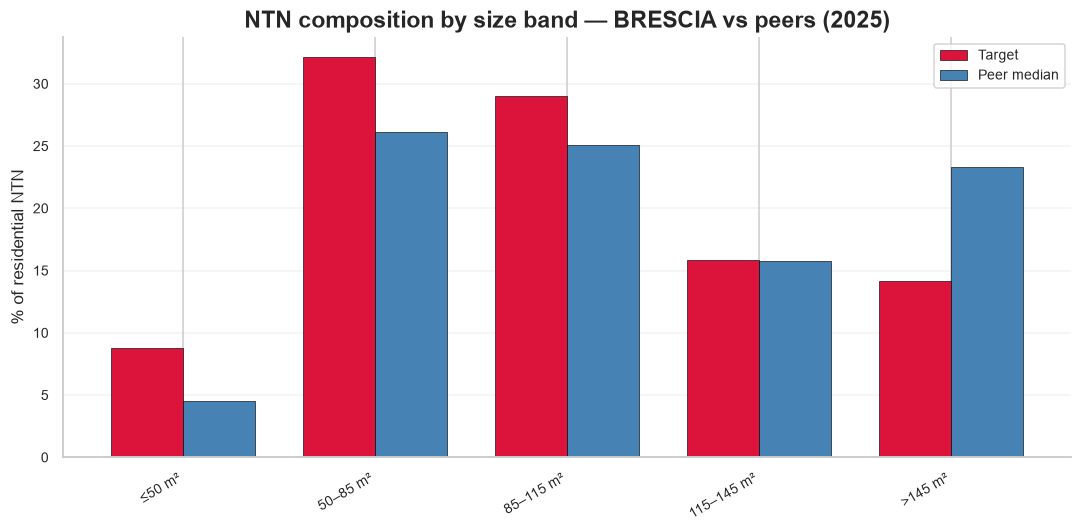

In [21]:
# Cell 21: Size-band composition comparison
size_fields = ["ntn_upto_50", "ntn_50_85", "ntn_85_115", "ntn_115_145", "ntn_over_145"]
size_labels = ["≤50 m²", "50–85 m²", "85–115 m²", "115–145 m²", ">145 m²"]

def size_mix(row: pd.Series) -> pd.Series:
    v = row[size_fields].astype(float)
    s = v.sum()
    return (v / s * 100) if s > 0 else pd.Series(np.nan, index=size_fields)

target_mix = size_mix(target)

peer_sizes  = peer_prov[size_fields].astype(float)
peer_totals = peer_sizes.sum(axis=1)
peer_mix    = peer_sizes.div(peer_totals, axis=0).mul(100).median()

mix = pd.DataFrame({
    "Target":      target_mix.values,
    "Peer median": peer_mix.values,
}, index=size_labels)

ax = mix.plot(kind="bar", figsize=(10, 5), width=0.75,
              color=["crimson", "steelblue"], edgecolor="black", linewidth=0.4)
ax.set(
    title=f"NTN composition by size band — {target['comune']} vs peers ({LATEST_YEAR})",
    ylabel="% of residential NTN",
)
ax.set_xticklabels(size_labels, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

> **Insight.** A market with an over-representation of small dwellings indicates a high-turnover, investor-oriented, or student-driven segment; an over-representation of large dwellings suggests family-oriented or luxury markets. Deviation from the peer median signals a distinctive housing mix.

---

## 9. Risk & Return Analytics

To provide a forward-looking perspective, the notebook computes three standard risk/return metrics on the historical quotation series:

- **CAGR** — compound annual growth rate, capturing smoothed long-run performance.
- **Volatility** — standard deviation of annual returns, a proxy for market risk.
- **Max Drawdown** — the largest peak-to-trough decline, capturing downside risk.

A minimum of three observations is required for the metrics to be computed; otherwise, values are reported as `NaN`.

In [22]:
# Cell 22: CAGR, volatility, and max drawdown
def safe_cagr(s: pd.Series, periods_per_year: int = PERIODS_PER_YEAR) -> float:
    s = s.dropna()
    if len(s) < 2 or s.iloc[0] <= 0:
        return np.nan
    n_periods = (len(s) - 1) * periods_per_year
    return (s.iloc[-1] / s.iloc[0]) ** (1 / n_periods) - 1

def safe_mdd(s: pd.Series) -> float:
    s = s.dropna()
    if s.empty:
        return np.nan
    return (s / s.cummax() - 1).min()

def annualised_volatility(s: pd.Series, periods_per_year: int = PERIODS_PER_YEAR) -> float:
    s = s.dropna().sort_index()
    if len(s) < 3:
        return np.nan
    return s.pct_change().dropna().std() * np.sqrt(periods_per_year)

def growth_risk(series: pd.Series) -> pd.Series:
    s = series.dropna().sort_index()
    if len(s) < MIN_OBS_FOR_RISK:
        return pd.Series({"CAGR": np.nan, "Volatility": np.nan, "Max Drawdown": np.nan})
    return pd.Series({
        "CAGR":         safe_cagr(s),
        "Volatility":   annualised_volatility(s),
        "Max Drawdown": safe_mdd(s),
    })

risk = pd.DataFrame({
    "Target":      growth_risk(target_hist),
    "Peer median": growth_risk(peer_hist),
})

display(risk.style.format("{:.2%}"))

,Target,Peer median
CAGR,-0.92%,-0.30%
Volatility,1.74%,2.05%
Max Drawdown,-12.10%,-7.66%


> **Insight.** A municipality with **higher CAGR and lower volatility** than its peers offers a superior risk-adjusted profile. A large negative max drawdown signals greater historical downside risk, which matters for investors with a limited tolerance for drawdowns.

---

## 10. Summary & Insights

This section consolidates the analytical results into a **single textual synthesis**, mapping each metric's percentile into a qualitative positioning label.

In [23]:
# Cell 23: Textual positioning summary
def describe_position(pct: float) -> str:
    if pd.isna(pct):  return "n/a"
    if pct >= 90:     return "top 10% (excellent)"
    if pct >= 75:     return "top quartile"
    if pct >= 50:     return "above median"
    if pct >= 25:     return "below median"
    if pct >= 10:     return "bottom quartile"
    return "bottom 10%"

def colour_position(val: str) -> str:
    if "excellent" in val or "top 10" in val:  return "background-color: #c6efce; color: #006100;"
    if "top quartile" in val:                   return "background-color: #d9f2d9; color: #006100;"
    if "above median" in val:                   return "background-color: #e6f7e6;"
    if "below median" in val:                   return "background-color: #fff2cc;"
    if "bottom quartile" in val:                return "background-color: #fce4d6; color: #833c00;"
    if "bottom 10" in val:                      return "background-color: #ffc7ce; color: #9c0006;"
    return ""

summary = benchmarks[key_show][["target", "peer_median", "target_percentile"]].copy()
summary["position"] = summary["target_percentile"].apply(describe_position)

print(f"\n=== Summary for {target['comune']} ({LATEST_YEAR}) — peer group: {key_show} ===")

styled = (
    summary.style
        .format({
            "target":            "{:,.2f}",
            "peer_median":       "{:,.2f}",
            "target_percentile": "{:.1f}%",
        })
)

# pandas >= 2.1 prefers DataFrame.map; fall back to applymap for older versions
if hasattr(styled, "map"):
    styled = styled.map(colour_position, subset=["position"])
else:
    styled = styled.applymap(colour_position, subset=["position"])

display(styled)


=== Summary for BRESCIA (2025) — peer group: Dimensional (region) ===


,target,peer_median,target_percentile,position
Residential NTN,"3,199.06",187.97,100.0%,top 10% (excellent)
Non-residential NTN,"4,379.94",237.81,100.0%,top 10% (excellent)
Total volume,"7,579.00",423.26,100.0%,top 10% (excellent)
Median quotation €/m²,"1,725.00","1,331.25",76.7%,top quartile
Median minimum quotation €/m²,"1,500.00","1,162.50",76.7%,top quartile
Median maximum quotation €/m²,"1,950.00","1,500.00",76.7%,top quartile
Median spread %,23.08,24.88,20.0%,bottom quartile


> **Insight.** The textual summary translates every quantitative percentile into an immediately interpretable label, allowing stakeholders to grasp the target's market positioning without inspecting the underlying numbers.

---

## 11. Export

All results are exported as CSV into `data/processed/benchmark/`, one file per peer group plus the risk table and the summary, enabling downstream integration with reporting tools or dashboards.

In [ ]:
# Cell 24: Export results to CSV
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
slug = target["comune"].lower().replace(" ", "_").replace("'", "")

def slugify(name: str) -> str:
    return (
        name.lower()
            .replace(" ", "_")
            .replace("(", "").replace(")", "")
            .replace("%", "pct")
            .replace(",", "").replace(".", "")
    )

# Benchmark files
for name, df in benchmarks.items():
    key = slugify(name)
    df.to_csv(BENCHMARK_DIR / f"{slug}_{key}.csv")

# Risk & summary
risk.to_csv(BENCHMARK_DIR / f"{slug}_risk_return.csv")
summary.to_csv(BENCHMARK_DIR / f"{slug}_summary.csv")

# Metadata
metadata = pd.DataFrame({
    "field": ["target_comune", "province", "region", "reference_year",
              "peer_group_used", "generated_at", "notebook"],
    "value": [target["comune"], target["Prov_n"], target["Regione_n"],
              LATEST_YEAR, key_show, pd.Timestamp.now().isoformat(),
              "04_omi_comune_peer_benchmark"],
})
metadata.to_csv(BENCHMARK_DIR / f"{slug}_metadata.csv", index=False)
for f in sorted(BENCHMARK_DIR.glob(f"{slug}_*")):
    print(f"  - {f.name}")

Outputs saved to: c:\Users\cc1323\italian-real-estate-analysis\data\processed\benchmark
  - brescia_dimensional_region.csv
  - brescia_metadata.csv
  - brescia_provincial.csv
  - brescia_risk_return.csv
  - brescia_summary.csv
  - brescia_top-30_provincial.csv


---

## Conclusion

This notebook has provided a **reproducible, three-dimensional peer benchmarking framework** for any Italian municipality, drawing on the analytical artefacts produced by the OMI quotation and transaction notebooks.

**Key capabilities:**
- Positioning against **three complementary peer groups** (provincial, dimensional, top-N).
- Scale-free comparison via **percentile ranks**.
- Historical **trend and indexed** comparisons that reveal relative performance.
- **Multivariate** positioning on the price-vs-volume plane.
- **Structural** analysis via size-band composition.
- **Risk/return** metrics (CAGR, volatility, max drawdown).
- Automated **CSV export** with audit metadata for downstream reporting.

**Next Steps:**
- Integrate **population** and **income** data to refine the peer definition and normalize transaction intensity per capita.
- Extend the analysis to **non-residential** segments at the same granularity.
- Feed the exported benchmark tables into a **dashboard** or a longitudinal tracking report to monitor how the positioning evolves over OMI releases.